<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Co-Kriging/blob/main/Co_Kriging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# California Housing Co-Kriging Analysis

1. Import Library
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Definisi Variabel Co-Kriging
5. Analisis Hubungan Z1-Z2
6. Persiapan Data Spasial
7. Pembagian Training Testing
8. Regression Co-Kriging Model
9. Evaluasi Model
10. Visualisasi Prediksi Spasial
11. Visualisasi Residual
12. Membuat Prediction Surface


# 1. Install Library

In [ ]:
!pip install pykrige

# 2. Import Library

In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


# upload file
from google.colab import files


# machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


# evaluasi
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# korelasi
from scipy.stats import pearsonr


# Co-Kriging
from pykrige.rk import RegressionKriging


print("Library berhasil dipanggil")

Library berhasil dipanggil


# 3. Upload Dataset

In [ ]:

uploaded = files.upload()

Saving housing.csv to housing (1).csv


# 4. Membaca Dataset

In [ ]:

filecose = list(uploaded.keys())[0]


df = pd.read_csv(filecose)


print("Nama file :", filecose)

print(
    "Jumlah data :",
    df.shape
)


df.head()

Nama file : housing (1).csv
Jumlah data : (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# 5. Cek Dataset

In [ ]:

df.info()


print("\nMissing Value")

print(
    df.isnull().sum()
)

df = df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

Missing Value
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
oc

# 6. Menentukan Variabel Co-Kriging
Z1 = Harga rumah
Z2 = Pendapatan
Koordinat = Latitude Longitude

In [ ]:

# Variabel utama Z1
Z1 = df[
    "median_house_value"
].values



# Variabel sekunder Z2
Z2 = df[
    [
        "median_income"
    ]
].values



# koordinat spasial

coordinate = df[
    [
        "longitude",
        "latitude"
    ]
].values


print("Z1 :", Z1.shape)

print("Z2 :", Z2.shape)

print("Coordinate :", coordinate.shape)

Z1 : (20433,)
Z2 : (20433, 1)
Coordinate : (20433, 2)


# 7. Analisis Hubungan Z1 dan Z2

In [ ]:

r,p = pearsonr(
    df["median_income"],
    df["median_house_value"]
)


print(
    "Koefisien Korelasi =",
    r
)


print(
    "P-value =",
    p
)

Koefisien Korelasi = 0.6883554753161123
P-value = 0.0


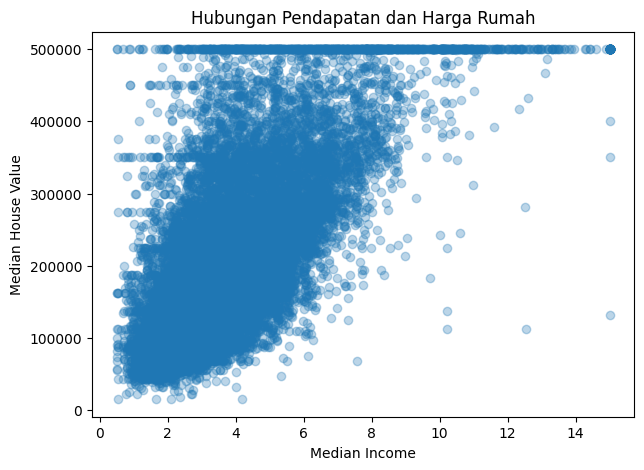

In [ ]:
plt.figure(figsize=(7,5))


plt.scatter(
    df["median_income"],
    df["median_house_value"],
    alpha=0.3
)


plt.xlabel(
    "Median Income"
)


plt.ylabel(
    "Median House Value"
)


plt.title(
    "Hubungan Pendapatan dan Harga Rumah"
)


plt.show()

In [ ]:
8. Membagi Data

In [ ]:

Z2_train, Z2_test, Z1_train, Z1_test, coord_train, coord_test = train_test_split(

    Z2,
    Z1,
    coordinate,

    test_size=0.2,
    random_state=42

)


print(
    "Data training:",
    len(Z1_train)
)


print(
    "Data testing:",
    len(Z1_test)
)

Data training: 16346
Data testing: 4087


# 9.Standardisasi dan Model Co-Kriging

In [ ]:

scaler = StandardScaler()


Z2_train = scaler.fit_transform(
    Z2_train
)


Z2_test = scaler.transform(
    Z2_test
)


model = RegressionKriging(

    regression_model=
    LinearRegression(),

    variogram_model=
    "spherical",

    n_closest_points=
    20

)



print("Model dibuat")

Model dibuat


# 10.Training Model

In [ ]:

model.fit(

    Z2_train,

    coord_train,

    Z1_train

)


print(
    "Training selesai"
)

Finished learning regression model
Finished kriging residuals
Training selesai


# 11. Prediksi

In [ ]:


prediction = model.predict(

    Z2_test,

    coord_test

)


print(
    prediction[:10]
)

/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.33792e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.28615e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.32193e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.27482e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.28011e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

[209124.06149389 164647.75961365 160897.86179782 194676.33196159
 138634.06275328  59858.60490556 298436.70171274 278160.73442476
 494678.95402685  69858.28892464]


# 12. Evaluasi Model

In [ ]:

RMSE = np.sqrt(
    mean_squared_error(
        Z1_test,
        prediction
    )
)


MAE = mean_absolute_error(
    Z1_test,
    prediction
)


R2 = r2_score(
    Z1_test,
    prediction
)


print("RMSE :", RMSE)

print("MAE  :", MAE)

print("R2   :", R2)

RMSE : 59198.50806414849
MAE  : 40211.23930320303
R2   : 0.7437355006965408


# 13. Peta Prediksi Co-Kriging

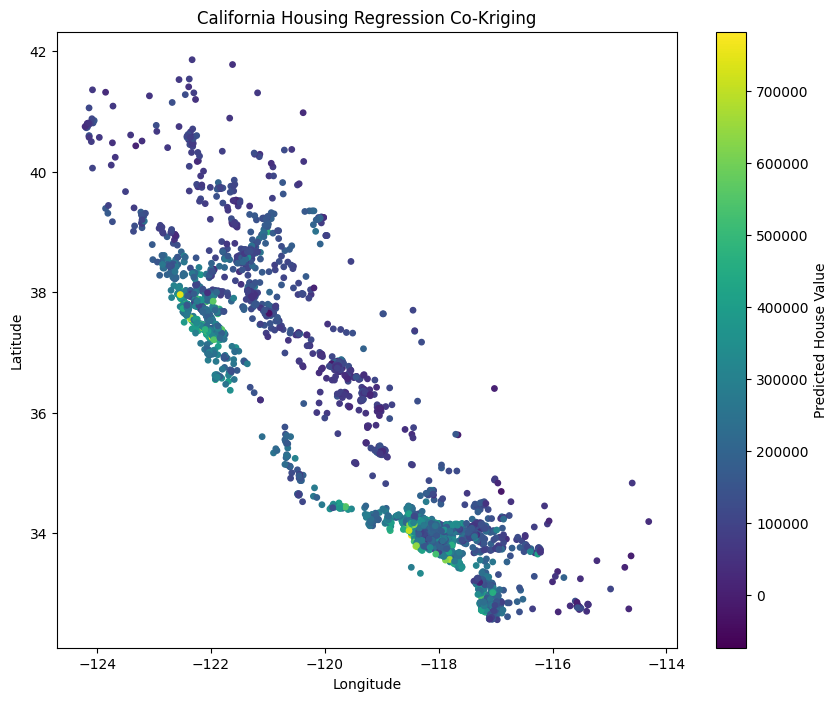

In [ ]:

plt.figure(
    figsize=(10,8)
)


plt.scatter(

    coord_test[:,0],

    coord_test[:,1],

    c=prediction,

    cmap="viridis",

    s=15

)


plt.colorbar(
    label="Predicted House Value"
)


plt.xlabel(
    "Longitude"
)


plt.ylabel(
    "Latitude"
)


plt.title(
    "California Housing Regression Co-Kriging"
)


plt.show()

# 14. Peta Residual

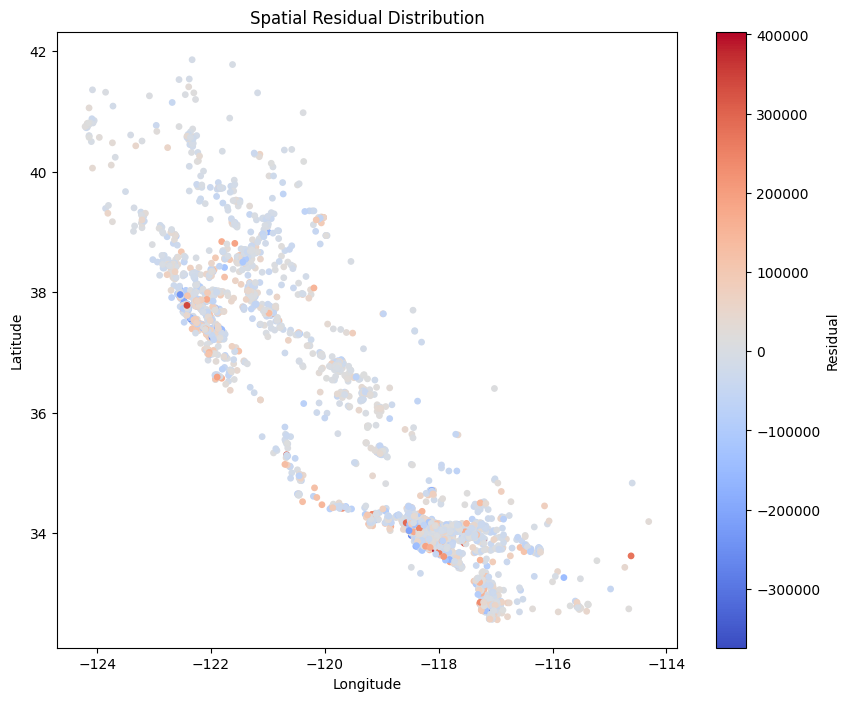

In [ ]:

residual = Z1_test - prediction


plt.figure(
    figsize=(10,8)
)


plt.scatter(

    coord_test[:,0],

    coord_test[:,1],

    c=residual,

    cmap="coolwarm",

    s=15

)


plt.colorbar(
    label="Residual"
)


plt.xlabel(
    "Longitude"
)


plt.ylabel(
    "Latitude"
)


plt.title(
    "Spatial Residual Distribution"
)


plt.show()